# Setup

## Imports

In [53]:
import time 
import sqlite3 

import cv2
import duckdb
import numpy as np
import pandas as pd
import sqlalchemy as db
import plotly.express as px
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
from PIL import Image
from scipy.spatial import distance
from huggingface_hub import hf_hub_download
from sklearn.preprocessing import MinMaxScaler


/home/amos/anaconda3/envs/face/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



## Plotly layout

In [2]:
layout = {
    'title': {
        'text': '',
        'font': {'size': 22, 'family': 'Raleway', 'color': 'white'},
        'x': 0.5,
        'y': 0.9,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    'xaxis': {
        'title': {
            'text': '',
            'font': {'size': 18, 'family': 'Raleway', 'color': 'white'} 
        },
        'tickfont': {'size': 14, 'family': 'Roboto', 'color': 'white'}
    },
    'yaxis': {
        'layer': 'below traces',
        'title': {
            'text': '',
            'font': {'size': 18, 'family': 'Raleway', 'color': 'white'} 
        },
        'tickfont': {'size': 14, 'family': 'Roboto', 'color': 'white'}
    },
    'font': {'color': 'white'},
    'paper_bgcolor': '#787577',
    'plot_bgcolor': 'rgba(61, 61, 61, 0)'
}

## Connect to db

In [59]:
cf_local_path = hf_hub_download(
    repo_id="astaileyyoung/CineFaceDB",
    filename="CineFace.duckdb",
    repo_type="dataset",
    local_dir="."
)

In [60]:
conn = duckdb.connect("./CineFace.duckdb")

In [61]:
dw_local_path = hf_hub_download(
    repo_id="astaileyyoung/CineFaceDB",
    filename="CineFaceDW.duckdb",
    repo_type="dataset",
    local_dir="."
)

In [62]:
dw_conn = duckdb.connect("CineFaceDW.duckdb")

# Funcs

### imdb_from_title

In [7]:
def imdb_from_title(title, conn):
    query = """
        SELECT 
            imdb_id
        FROM dimWork
        WHERE title = $title
    """
    imdb_id = conn.execute(query, {"title": title}).fetchone()[0]
    return imdb_id

### calculate_peak_density

In [8]:
def calculate_peak_density(face_coords, radius=0.05):
    """
    face_coords: Nx2 array of normalized (x, y) centers (0.0 to 1.0)
    radius: The circular 'buffer' around the peak (0.05 = 5% of screen)
    """
    # 1. Create a 2D Histogram to find the 'Max Pixel Point' area
    # We use a 50x50 grid to find the general 'Peak'
    heatmap, xedges, yedges = np.histogram2d(
        face_coords[:, 0], face_coords[:, 1], bins=50, range=[[0, 1], [0, 1]]
    )
    
    # 2. Find the coordinates of the Peak Bin
    max_idx = np.unravel_index(heatmap.argmax(), heatmap.shape)
    peak_x = (xedges[max_idx[0]] + xedges[max_idx[0] + 1]) / 2
    peak_y = (yedges[max_idx[1]] + yedges[max_idx[1] + 1]) / 2
    peak_point = np.array([peak_x, peak_y])

    # 3. Calculate distance of ALL faces from this Peak Point
    distances = distance.cdist(face_coords, [peak_point], 'euclidean').flatten()

    # 4. Calculate Density Metrics
    total_faces = len(face_coords)
    faces_in_peak = np.sum(distances <= radius)
    
    peak_concentration = (faces_in_peak / total_faces) * 100
    avg_dist_from_peak = np.mean(distances)

    return {
        "peak_location": (peak_x, peak_y),
        "peak_concentration_pct": peak_concentration,
        "avg_dist_from_peak": avg_dist_from_peak,
        "max_bin_frequency": np.max(heatmap)
    }

### to_color

In [9]:
def to_color(frame,
             colormap=cv2.COLORMAP_VIRIDIS):
    return cv2.applyColorMap(frame.astype(np.uint8), colormap)

### find_most_common_face_spot

In [10]:
def find_most_common_face_spot(df, sigmaX=30):
    h, w = int(df['img_height'].iloc[0]), int(df['img_width'].iloc[0])
    
    # Use the SAME technique as your bounding box approach!
    # But with small boxes around centers
    diff = np.zeros((h + 1, w + 1), dtype=np.float32)
    
    # Get centers
    cx = ((df['x1'] + df['x2']) / 2).astype(int).values
    cy = ((df['y1'] + df['y2']) / 2).astype(int).values
    
    # Create small boxes around each center (instead of points)
    splat_size = 10  # Half-width of splat box
    x1 = np.clip(cx - splat_size, 0, w)
    y1 = np.clip(cy - splat_size, 0, h)
    x2 = np.clip(cx + splat_size, 0, w)
    y2 = np.clip(cy + splat_size, 0, h)
    
    # Use your difference array technique
    np.add.at(diff, (y1, x1), 1)
    np.add.at(diff, (y1, x2), -1)
    np.add.at(diff, (y2, x1), -1)
    np.add.at(diff, (y2, x2), 1)
    
    # Compute cumulative sum
    heatmap = diff.cumsum(axis=0).cumsum(axis=1)[:-1, :-1]
    
    # Blur to smooth
    heatmap = cv2.GaussianBlur(heatmap, (0, 0), sigmaX=sigmaX)
    
    # Normalize
    heatmap = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Find peak
    _, _, _, max_loc = cv2.minMaxLoc(heatmap)
    
    return heatmap

### draw_gridlines

In [11]:
def draw_gridlines(img):
    h, w = img.shape[:2]
    # Use a semi-transparent or soft white/grey
    # OpenCV uses BGR: (Blue, Green, Red)
    line_color = (200, 200, 200) 
    thickness = 2

    # Vertical lines (at 1/3 and 2/3 of width)
    cv2.line(img, (int(w / 3), 0), (int(w / 3), h), line_color, thickness)
    cv2.line(img, (int(2 * w / 3), 0), (int(2 * w / 3), h), line_color, thickness)

    # Horizontal lines (at 1/3 and 2/3 of height)
    cv2.line(img, (0, int(h / 3)), (w, int(h / 3)), line_color, thickness)
    cv2.line(img, (0, int(2 * h / 3)), (w, int(2 * h / 3)), line_color, thickness)
    
    return img

### create_heatmap_from_title

In [12]:
def create_heatmap_from_title(title, conn, year=None, resize=False, grid=False, sigmaX=30):
    query = f"""
    SELECT
        face.imdb_id,
        face.frame_num,
        face.x1,
        face.y1,
        face.x2,
        face.y2,
        di.img_width AS img_width,
        di.img_height AS img_height,
        work.year
    FROM face
    INNER JOIN work ON work.imdb_id = face.imdb_id
    INNER JOIN detection_info di ON work.imdb_id = di.imdb_id
    WHERE work.title LIKE '{title}'
    """
    if year:
        query += f" AND work.year = {year}"
    df = pd.read_sql_query(query, conn)
    year = df.at[0, 'year']
    
    frame = find_most_common_face_spot(df, sigmaX=sigmaX)

    h, w = frame.shape[:2]
    ratio = w / h
    if resize and isinstance(resize, int):
        print("Ratio: ", ratio)
        if h > resize:
            hh = resize
            ww = int(ratio * hh)
            frame = cv2.resize(frame, (ww, hh))
    elif resize:
        print("Resize argument must be int.")
        return 
    # x, y = find_max_new(frame)
    color = to_color(frame, colormap=cv2.COLORMAP_TURBO)
    if grid:
        color = draw_gridlines(color)
        
    # color = draw_crosshairs(color, x, y)
    img = Image.fromarray(cv2.cvtColor(color, cv2.COLOR_BGR2RGB))

    display(img)

### process_faces

In [13]:
def process_faces(df):
    h = int(df.at[0, 'img_height'])
    w = int(df.at[0, 'img_width'])
    mask = np.zeros(shape=(h, w), dtype=int)
    
    # Calculate all centers at once
    cx = ((df['x1'] + df['x2']) / 2).astype(int).values
    cy = ((df['y1'] + df['y2']) / 2).astype(int).values
    
    # Filter valid coordinates
    valid = (cx >= 0) & (cx < w) & (cy >= 0) & (cy < h)
    cx = cx[valid]
    cy = cy[valid]
    
    # Accumulate at center points (just increment by 1 each time)
    np.add.at(mask, (cy, cx), 1)
    
    return mask

### create_grid

In [14]:
def create_grid(mask):
    grid = np.zeros(shape=(3, 3))
    rx = int(mask.shape[1]/3)
    ry = int(mask.shape[0]/3)
    a = [x * rx for x in range(1, 4)]
    b = [x * ry for x in range(1, 4)]
    for ii, i in enumerate(a):
        for ij, j in enumerate(b):
            xi = i - rx
            yi = j - ry
            temp = mask[yi:j, xi:i].sum()
            grid[ij, ii] = temp/mask.sum()
    return grid

### create_gridmap_from_title

In [15]:
def create_gridmap_from_title(title, conn, year=None, layout=None, size=600):
    query = f"""
        SELECT
            face.imdb_id,
            face.frame_num,
            face.x1,
            face.y1,
            face.x2,
            face.y2,
            di.img_width AS img_width,
            di.img_height AS img_height,
            work.year
        FROM face
        INNER JOIN work ON work.imdb_id = face.imdb_id
        INNER JOIN detection_info di ON work.imdb_id = di.imdb_id
        WHERE work.title LIKE '{title}'
    """
    if year:
        query += f" AND work.year = {year}"
        
    df = pd.read_sql_query(query, conn)
    year = df.at[0, 'year']
    
    mask = process_faces(df)
    grid = create_grid(mask)

    flat_grid = grid.flatten()
    concentration_score = np.sqrt(np.mean((flat_grid - 0.1111)**2))

    print(f"Concentration Score: {concentration_score:.4f}")

    fig = px.imshow(np.round(grid, 3),
                    x=['Left', 'Middle', 'Right'],
                    y=['Top', 'Center', 'Bottom'],
                    labels={'color': 'Face Percent by Section'},
                    text_auto=True,
                    aspect='equal',
                    color_continuous_scale='Aggrnyl'
    )
    fig.update_layout(layout)
    fig.update_layout(
        title={
            "text": title if title else "",
            "x": 0.5,
            "xanchor": "center",
            "yanchor": "top"
        },
        width=size,
        height=size,
        xaxis=dict(side="bottom"),
        yaxis=dict(autorange="reversed"), 
        margin=dict(l=50, r=50, t=80, b=50),
        coloraxis_colorbar=dict(title="Delta %"),
        xaxis_title="Horizontal Position",
        yaxis_title="Vertical Position",
        template="plotly_dark"
    )
    
    fig.show()

### create_gridmap_from_director

In [16]:
def create_gridmap_from_director(title, conn, year=None, layout=None):
    query = f"""
        SELECT
            face.imdb_id,
            face.frame_num,
            face.x1,
            face.y1,
            face.x2,
            face.y2,
            video.width AS img_width,
            video.height AS img_height,
            work.year
        FROM face
        INNER JOIN work ON work.imdb_id = face.imdb_id
        INNER JOIN video ON video.video_id = work.video_id
        WHERE work.title LIKE '{title}'
    """
    if year:
        query += f" AND work.year = {year}"
        
    df = pd.read_sql_query(query, conn)
    year = df.at[0, 'year']
    
    mask = process_faces(df)
    grid = create_grid(mask)
    fig = px.imshow(np.round(grid, 3),
                    x=['Left', 'Center', 'Right'],
                    y=['Top', 'Middle', 'Bottom'],
                    labels={'color': 'Face Percent by Section'},
                    text_auto=True,
                    aspect='auto',
                    color_continuous_scale='Aggrnyl')
    if layout:
        fig.update_layout(layout)
    fig.update_layout(title={'text': f'Gridmap of Face Locations in {title} ({year})',
                            'y': 0.95})
    fig.show()

## Compare Film to Sample

#### create_heatmap_array

In [17]:
def create_heatmap_array(df, bins=500, sigma=25):
    # 1. Create 2D Histogram
    heatmap, xedges, yedges = np.histogram2d(
        df['norm_y'], df['norm_x'], 
        bins=bins, range=[[0, 1], [0, 1]]
    )
    
    # 2. Apply Gaussian Blur to smooth out the "dots"
    heatmap = ndimage.gaussian_filter(heatmap, sigma=sigma)
    
    # 3. Normalize so the entire map sums to 1 (Probability Density)
    return heatmap / np.sum(heatmap)

#### get_global_baseline

In [18]:
def get_global_baseline(conn, sample_size=10000):
    # We use CRC32 because it's much faster than MD5 for simple sampling
    # It turns the 'movie+frame+face' combo into a number, then we pick a slice of those numbers
    query = """
        SELECT 
            (f.x1 + f.x2) / (2.0 * v.width) as norm_x, 
            (f.y1 + f.y2) / (2.0 * v.height) as norm_y
        FROM face f
        JOIN video v ON f.video_id = v.video_id
        WHERE HASH(f.imdb_id, f.frame_num, f.face_num) % 100 = 0
        LIMIT $sample_size
    """
    params = {"sample_size": sample_size}
    global_baseline_df = conn.execute(query, params).df()
    return global_baseline_df
    

#### get_global_baseline_grid

In [19]:
def get_global_baseline_grid(conn):
    # We use CRC32 because it's much faster than MD5 for simple sampling
    # It turns the 'movie+frame+face' combo into a number, then we pick a slice of those numbers
    query = """
        SELECT
            -- Top Row
            AVG(pct_faces_top_left) AS avg_top_left,
            AVG(pct_faces_top_center) AS avg_top_center,
            AVG(pct_faces_top_right) AS avg_top_right,
            
            -- Middle Row
            AVG(pct_faces_mid_left) AS avg_middle_left,
            AVG(pct_faces_mid_center) AS avg_middle_center,
            AVG(pct_faces_mid_right) AS avg_middle_right,
            
            -- Bottom Row
            AVG(pct_faces_bot_left) AS avg_bottom_left,
            AVG(pct_faces_bot_center) AS avg_bottom_center,
            AVG(pct_faces_bot_right) AS avg_bottom_right
        FROM factWork
    """
    global_baseline_df = conn.execute(query).df()
    return global_baseline_df
    

#### plot_comparison

In [20]:
def plot_comparison(residual, title="The Welles Signature: Deviations from Hollywood Norms"):
    # Calculate the symmetric limit so 0 is exactly in the center of the color scale
    limit = max(abs(residual.min()), abs(residual.max()))
    
    fig = px.imshow(
        residual,
        # 'RdBu_r' equivalent in Plotly is 'RdBu' (it is already reversed by default)
        color_continuous_scale='RdBu_r', 
        range_color=[-limit, limit],
        labels=dict(x="Horizontal Position", y="Vertical Position", color="Deviation"),
        x=np.linspace(0, 1, residual.shape[1]),
        y=np.linspace(0, 1, residual.shape[0]),
        title=title,
        aspect="auto"
    )

    # Configure the 'Camera coordinate' layout
    fig.update_layout(layout)
    fig.update_layout(
        xaxis=dict(title="Horizontal Screen Position", range=[0, 1]),
        # Inverting Y to match standard image/video top-down coordinates
        yaxis=dict(title="Vertical Screen Position", range=[1, 0]),
        coloraxis_colorbar=dict(title="Deviation"),
        # template="plotly_dark",
        width=800,
        height=700
    )

    # Add a zero-line to the colorbar or annotations if needed
    fig.show()

# def plot_comparison(residual):
#     plt.figure(figsize=(10, 8))
#     # 'RdBu_r' gives Red for positive, Blue for negative
#     # vmax and vmin should be anchored at the same distance from 0
#     limit = max(abs(residual.min()), abs(residual.max()))

#     plt.imshow(residual, cmap='RdBu_r', extent=[0, 1, 1, 0], vmin=-limit, vmax=limit)
#     plt.colorbar(label='Deviation from Industry Standard')
#     plt.title("The Welles Signature: Deviations from Hollywood Norms")
#     plt.xlabel("Horizontal Screen Position")
#     plt.ylabel("Vertical Screen Position")
#     plt.show()

#### plot_global_average

In [21]:
def plot_global_average(df, title="The 'Hollywood Bullseye': Industry Average Framing"):
    # 1. Generate the heatmap array 
    avg_map = create_heatmap_array(df)
    
    # 2. Create the base Heatmap
    fig = px.imshow(
        avg_map,
        labels=dict(x="Horizontal Position", y="Vertical Position", color="Density"),
        x=np.linspace(0, 1, avg_map.shape[1]),
        y=np.linspace(0, 1, avg_map.shape[0]),
        color_continuous_scale='Turbo',
        title=title,
        aspect="auto"
    )

    # 3. Add Rule of Thirds Overlay (using shapes)
    rule_of_thirds_lines = []
    for pos in [1/3, 2/3]:
        # Vertical lines
        rule_of_thirds_lines.append(dict(
            type="line", x0=pos, x1=pos, y0=0, y1=1,
            line=dict(color="white", width=2, dash="dash"), opacity=0.4
        ))
        # Horizontal lines
        rule_of_thirds_lines.append(dict(
            type="line", x0=0, x1=1, y0=pos, y1=pos,
            line=dict(color="white", width=2, dash="dash"), opacity=0.4
        ))

    # 4. Update Layout for the "Camera View" feel
    fig.update_layout(layout)
    
    fig.update_layout(
        shapes=rule_of_thirds_lines,
        xaxis=dict(range=[0, 1], title="Normalized Width"),
        yaxis=dict(range=[1, 0], title="Normalized Height"), # Invert Y to match image coordinates
        width=800,
        height=600,
        # template="plotly_dark" # Dark theme looks great for film data
    )

    fig.show()

# def plot_global_average(df, title="The 'Hollywood Bullseye': Industry Average Framing"):
#     # Generate the map from your 10k sample
#     avg_map = create_heatmap_array(df)
    
#     plt.figure(figsize=(10, 8))
#     # Use 'magma' or 'hot' for single-density maps
#     plt.imshow(avg_map, cmap='magma', extent=[0, 1, 1, 0])
    
#     # Overlay the 'Rule of Thirds' so we can see the alignment
#     for pos in [1/3, 2/3]:
#         plt.axvline(x=pos, color='white', linestyle='--', alpha=0.3)
#         plt.axhline(y=pos, color='white', linestyle='--', alpha=0.3)
#         #
#     plt.colorbar(label='Face Density')
#     plt.title(title)
#     plt.xlabel("Horizontal Position (Normalized)")
#     plt.ylabel("Vertical Position (Normalized)")
#     plt.show()

#### plot_grid

In [22]:
def plot_grid(grid, plot_title=None, size=600):
    # Center the color scale at zero
    limit = max(abs(grid.min()), abs(grid.max()))
    
    fig = px.imshow(
        grid,
        x=['Left', 'Middle', 'Right'],
        y=['Top', 'Center', 'Bottom'],
        color_continuous_scale='Aggrnyl', 
        range_color=[-limit, limit],
        text_auto=".3f", # This shows the difference value in each box
        title=plot_title if plot_title else "",
        aspect="equal"
    )

    fig.update_layout(layout)
    fig.update_layout(
        title={
            "text": plot_title if plot_title else "",
            "x": 0.5,
            "xanchor": "center",
            "yanchor": "top"
        },
        width=size,
        height=size,
        xaxis=dict(side="bottom"),
        yaxis=dict(autorange="reversed"), 
        margin=dict(l=50, r=50, t=80, b=50),
        coloraxis_colorbar=dict(title="Delta %"),
        xaxis_title="Horizontal Position",
        yaxis_title="Vertical Position",
        template="plotly_dark"
    )
    
    fig.show()

#### get_sample_grid

In [23]:
def get_sample_grid(conn):
    query = """
        SELECT 
            AVG(pct_faces_top_left) as tl, AVG(pct_faces_top_center) as tc, AVG(pct_faces_top_right) as tr,
            AVG(pct_faces_mid_left) as ml, AVG(pct_faces_mid_center) as mc, AVG(pct_faces_mid_right) as mr,
            AVG(pct_faces_bot_left) as bl, AVG(pct_faces_bot_center) as bc, AVG(pct_faces_bot_right) as br
        FROM factWork
    """
    df = conn.execute(query).df()
    grid = df.values.reshape(3, 3)
    grid_norm = grid / grid.sum()
    return grid_norm

#### plot_sample_grid

In [24]:
def plot_sample_grid(conn, plot_title=None):
    grid_norm = get_sample_grid(conn)
    plot_grid(grid_norm, plot_title=plot_title)

#### compare_film_to_sample_heat

In [25]:
def compare_film_to_sample_heat(title, conn):    
    imdb_id = conn.execute(
        """
            SELECT
                imdb_id
            FROM work 
            WHERE title LIKE $title
        """, 
        {"title": title}
    ).fetchone()[0]

    global_baseline_df = get_global_baseline(conn)
    
    query = """
        SELECT (f.x1 + f.x2) / (2.0 * v.width) as norm_x, 
            (f.y1 + f.y2) / (2.0 * v.height) as norm_y
        FROM face f
        JOIN video v ON f.video_id = v.video_id
        WHERE f.imdb_id = $imdb_id
    """
    ck_df = pd.read_sql_query(query, conn, params={"imdb_id": imdb_id})

    standard_map = create_heatmap_array(global_baseline_df)
    ck_map = create_heatmap_array(ck_df)

    residual = ck_map - standard_map
    plot_comparison(residual)


#### compare_film_to_sample_grid

In [26]:
def compare_film_to_sample_grid(title, conn, plot_title=None):
    # global_avg_query = """
    #     SELECT 
    #         AVG(pct_faces_top_left) as tl, AVG(pct_faces_top_center) as tc, AVG(pct_faces_top_right) as tr,
    #         AVG(pct_faces_mid_left) as ml, AVG(pct_faces_mid_center) as mc, AVG(pct_faces_mid_right) as mr,
    #         AVG(pct_faces_bot_left) as bl, AVG(pct_faces_bot_center) as bc, AVG(pct_faces_bot_right) as br
    #     FROM factWork
    # """
    # # Get the first row of results
    # avg_row = conn.execute(global_avg_query).fetchone()
    # # Map to a 3x3 numpy array
    # avg_grid = np.array(avg_row).reshape(3, 3)
    # avg_grid_norm = avg_grid / avg_grid.sum()

    avg_grid_norm = get_sample_grid(conn)

    imdb_id = imdb_from_title(title, conn)
    query = """
        SELECT
            pct_faces_top_left,
            pct_faces_top_center,
            pct_faces_top_right,
            pct_faces_mid_left,
            pct_faces_mid_center,
            pct_faces_mid_right,
            pct_faces_bot_left,
            pct_faces_bot_center,
            pct_faces_bot_right
        FROM factWork
        WHERE imdb_id = $imdb_id
    """
    df = conn.execute(query, {"imdb_id": imdb_id}).df()
    title_grid = np.array(df.values).reshape(3, 3)

    diff_grid = title_grid - avg_grid_norm
    plot_grid(diff_grid, plot_title=plot_title)

## Compare to Sample Z Score

### get_movie_score

In [27]:
def get_movie_centering_score(imdb_id, engine, lower_bound=0.25, upper_bound=0.75):
    query = """
        SELECT (f.x1 + f.x2) / (2.0 * v.width) as norm_x, 
               (f.y1 + f.y2) / (2.0 * v.height) as norm_y
        FROM face f
        JOIN video v ON f.video_id = v.video_id
        WHERE f.imdb_id = :imdb_id
    """
    with engine.connect() as conn:
        df = pd.read_sql_query(db.text(query), conn, params={"imdb_id": imdb_id})
    
    if df.empty:
        return None

    # Calculate what % of faces fall in the center 25% of the screen
    in_center = df[
        (df['norm_x'] > lower_bound) & (df['norm_x'] < upper_bound) &
        (df['norm_y'] > lower_bound) & (df['norm_y'] < upper_bound)
    ]
    
    return len(in_center) / len(df)

### get_historical_zscore

In [28]:
def get_historical_zscore(imdb_id, engine):
    with engine.connect() as conn:
        # Get the year for this work
        year = conn.execute(
            db.text("SELECT year FROM dimWork WHERE imdb_id = :imdb_id"), 
            {"imdb_id": imdb_id}
        ).scalar()
        
        if not year:
            return None, None
        
        baseline = conn.execute(db.text("""
            SELECT mu_distance, sigma_distance, mu_variance, sigma_variance
            FROM vwFramingBaseline 
            WHERE year = :year
        """), {"year": year}).fetchone()
        
        if not baseline:
            return None, None
        
        work_stats = conn.execute(db.text("""
            SELECT avg_face_distance_from_center, stddev_face_distance_from_center
            FROM factWork
            WHERE imdb_id = :imdb_id
        """), {"imdb_id": imdb_id}).fetchone()
        
        if not work_stats:
            return None, None
        
        # Z-score for average distance (centering)
        z_avg = (work_stats.avg_face_distance_from_center - baseline.mu_distance) / baseline.sigma_distance if baseline.sigma_distance else None
        
        # Z-score for standard deviation (consistency)
        z_variance = (work_stats.stddev_face_distance_from_center - baseline.mu_variance) / baseline.sigma_variance if baseline.sigma_variance else None
        
        return z_avg, z_variance


# Framing

## Heatmap

### Local Average

/tmp/ipykernel_44328/1056274907.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


Ratio:  1.3703703703703705


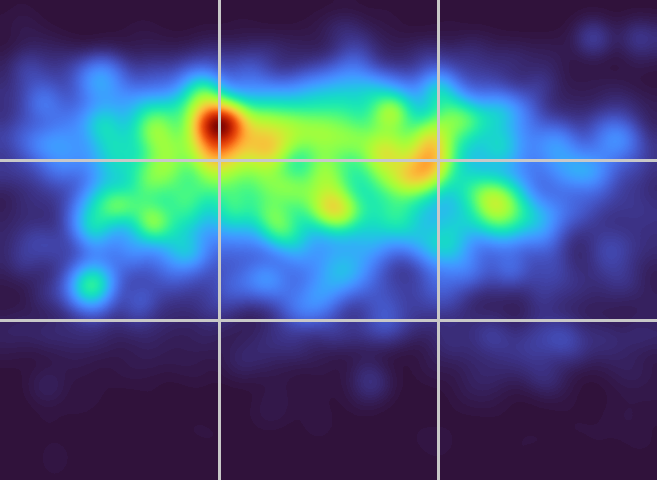

In [29]:
create_heatmap_from_title('Citizen Kane', conn, resize=480, grid=True)

### Global Average

The above heatmap is normalized by the film, as in the most frequent spot where faces occur in the image gets a value of 1 and the rest between 0 and 1. This does not less us compare one film to another, however. To see how one film compares to the entire dataset, we need to calculate the global average.  

In [30]:
global_baseline_df = get_global_baseline(conn)
plot_global_average(global_baseline_df)

In [31]:
title = "Citizen Kane"

In [32]:
compare_film_to_sample_heat(title, conn)

/tmp/ipykernel_44328/71994283.py:21: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



## Rule of Thirds

<font size=4 face='georgia'>
The following is from the <i>Oxford Dictionary of Film Studies</i> written by Annette Kuhn and Guy Westell on the phrase "rule of thirds":
<blockquote>
A flexible compositional ‘rule’ taught as part of painting and
photographic practice and which may be extended to the framing of shots
in filmmaking. Its aim is to indicate where significant elements may be
placed in the frame in order to attract the viewer’s attention, and also
produce a well composed—visually coherent and harmonious—image. This
•
idea of composition, based on geometrical principles, stems from ideas
developed from the ancient Greek and Roman periods which still hold sway
in Western culture today, the argument being that geometrical ‘rules’ follow
the ‘rules’ of nature. The rule of thirds ordains that the frame be divided
into thirds both vertically and horizontally: if lines were drawn to mark
these thirds they would look like the grid used to play noughts and crosses,
but with flatter rectangular spaces. The intersections of the four gridlines
represent the approximate points where objects in the frame would be
placed. In the case of filmed closeups, for example, the subject’s eyes
would be lined up to match the upper horizontal third. However,
conventions of composition change and develop, and in filmmaking centred
framings are more common than those using rule of thirds. (355)
</blockquote>
</font>

In [33]:
film_title = "Citizen Kane"
year = 1941

/tmp/ipykernel_44328/1056274907.py:20: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



Ratio:  1.3703703703703705


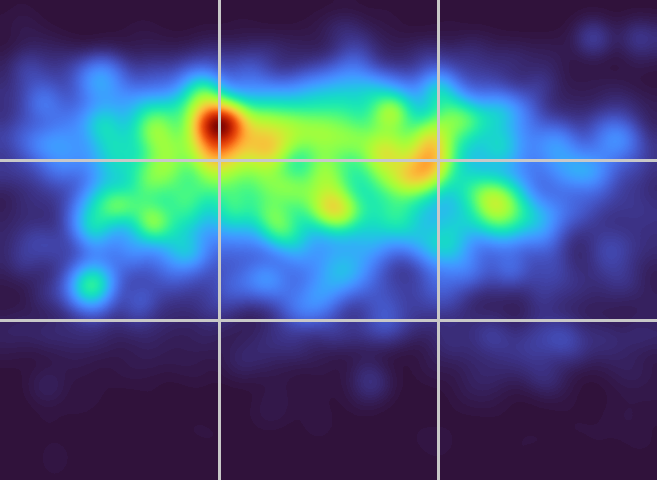

Concentration Score: 0.0841


/tmp/ipykernel_44328/849762663.py:21: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



In [34]:
create_heatmap_from_title(film_title, conn, year=year, resize=480, grid=True, sigmaX=30)
create_gridmap_from_title(film_title, conn, year=year, layout=layout)

We can do the same thing with the gridmap as with the heatmap. The plot below shows the average difference per grid cell.

In [35]:
compare_film_to_sample_grid(film_title, dw_conn, plot_title=f"{title} ({year})")

In [36]:
0.027 - 0.066 - 0.032 + 0.058 -0.021 + 0.02 + 0.001 + 0.004 + 0.009

-1.734723475976807e-18

As you can see, Citizen Kane is much less centered than the average film. Both middle-center and the middle-top have less faces than the typical film. Those cells are usually the most common area for faces to appear. The average face locations for the entire sample are shown below.

In [37]:
plot_sample_grid(dw_conn, plot_title="Industry Baseline")

In [38]:
0.113 + 0.283 + 0.112 + 0.101 + 0.268 + 0.102 + 0.007 + 0.007 + 0.007

1.0

## Measuring Framing

The heatmap shows us the frequency of face locations in the image, but the image is rather useless for analysis. In order to compare one film to another, We need a way of measuring the "concentration" of face positions within the frame.

In [63]:
query = """
    SELECT 
        dw.year,
        AVG(composition_gini) AS composition_gini,
        AVG(peak_concentration) AS peak_concentration,
        AVG(z_composition_gini) AS z_composition_gini,
        AVG(avg_dispersion) AS avg_disperation
    FROM factWork fw
    INNER JOIN dimWork dw ON fw.work_id = dw.work_id
    GROUP BY dw.year
    HAVING COUNT(*) > 50
"""
df = dw_conn.execute(query).df()
df

,year,composition_gini,peak_concentration,z_composition_gini,avg_disperation
0,1931,0.553381,NaN,3.624607e-09,NaN
1,1932,0.545487,NaN,2.743626e-09,NaN
2,1933,0.519882,NaN,-1.984604e-09,NaN
3,1934,0.519862,NaN,5.112140e-09,NaN
4,1935,0.522535,NaN,3.980947e-09,NaN
...,...,...,...,...,...
87,2021,0.526430,NaN,-1.256459e-09,NaN
88,2022,0.511430,NaN,1.839650e-10,NaN
89,2023,0.521320,NaN,5.645842e-10,NaN
90,2024,0.526804,NaN,-2.631504e-09,NaN


In [51]:
fig = px.line(df, x='year', y='composition_gini', color_discrete_sequence=["#79b8b8"])
fig.update_layout(layout)
fig.update_traces(line_width=4)
fig.show()

### Z Score

Z Score is a relatively simple statistical measure. It measures how many standard deviations once is from the mean. 

In [41]:
imdb_id = imdb_from_title("Citizen Kane", engine)
imdb_id

NameError: name 'engine' is not defined

In [ ]:
get_historical_zscore(imdb_id, dw_engine)

(0.387733635900995, 1.3608955271750114)

### Dispersion

The first strategy is measure how concentrated the face images are around the pixel that crosses through the most face images. 